In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys
import os
import tqdm

# This (hopefully) sets the root directory for anyone using the repo
cwd = os.getcwd()  # poison-perf/poisoning/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, RGD_audit, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_binary_classification_nd,setup_non_convex_1d, setup_2d_non_linear_experiment, setup_non_convex_nd
# from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.black_box import black_box_naive, black_box_orthogonal, black_box_cluster
from poisoning.shadow import black_box_shadow_logreg, black_box_shadow_logreg_nd
from utils.plotting import plot_results_1d, plot_results_2d

# Binary Classification

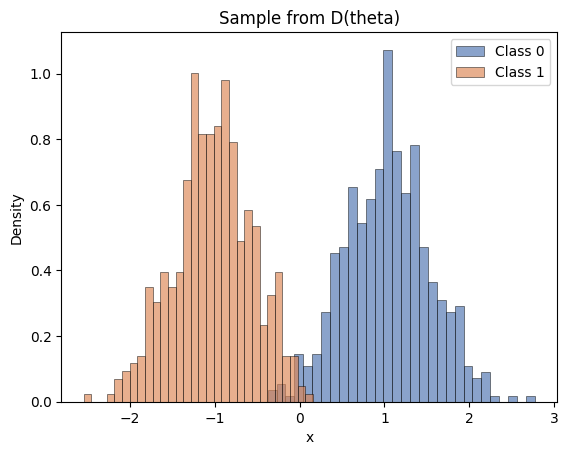

In [2]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)

x, y = D_theta(n=1000, theta=theta_0)

# prettier colors and styled histograms
colors = ['#4C72B0', '#DD8452']  # muted blue and warm orange

x0 = x[(y == 0).bool()].numpy()
x1 = x[(y == 1).bool()].numpy()

plt.hist(x0, bins=30, density=True, alpha=0.65, color=colors[0],
         edgecolor='k', linewidth=0.5, label='Class 0')
plt.hist(x1, bins=30, density=True, alpha=0.65, color=colors[1],
         edgecolor='k', linewidth=0.5, label='Class 1')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sample from D(theta)')
plt.legend(frameon=True)
plt.show()

## Untargeted Shadow Model Poisoning

### Visualize Effect of Black Box Poisoning on Clusters

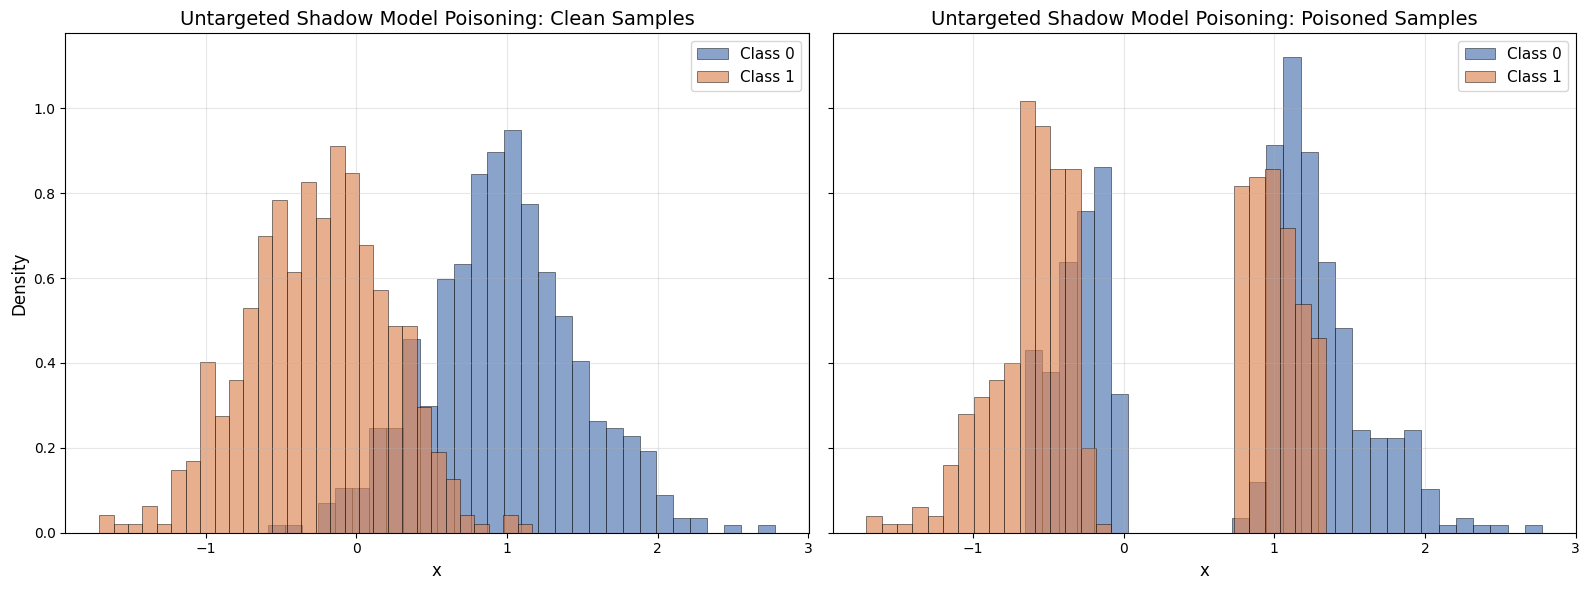

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'Untargeted Shadow Model Poisoning: Clean Samples'}, xlabel='x', ylabel='Density'>,
  <Axes: title={'center': 'Untargeted Shadow Model Poisoning: Poisoned Samples'}, xlabel='x'>))

In [3]:
# Visualize poisoning effect on samples
from utils.plotting import plot_clean_vs_poisoned_samples

# Set up parameters
black_box_poison_function = black_box_shadow_logreg
epsilon = 0.5
delta = 1.0
n = 1000
eta = 0.05
max_iter = 30
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

# Run RGD with return_samples=True to get clean and poisoned samples
_, _, z_clean, z_poisoned = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    poison_function=black_box_poison_function,
    normalize_grad=False,
    return_samples=True,  # This returns z_clean and z_poisoned
    epsilon=epsilon,
    delta=delta
)

# Visualize the comparison
plot_clean_vs_poisoned_samples(z_clean, z_poisoned, title_prefix="Untargeted Shadow Model Poisoning: ")

## RGD + Shadow Model Untargeted

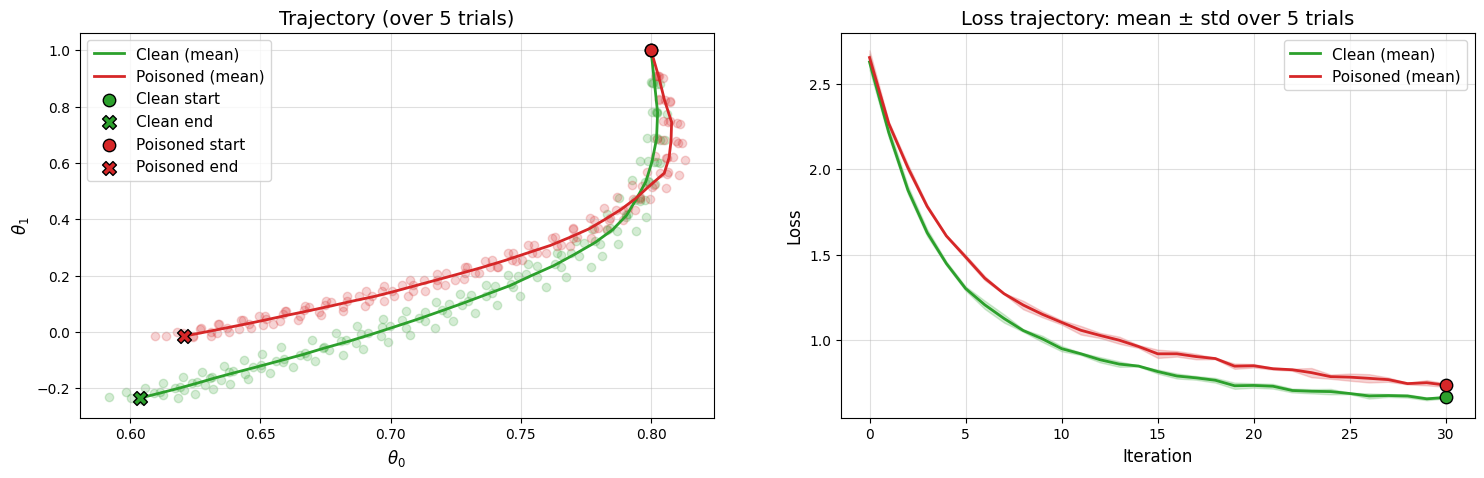

In [4]:
black_box_poison_function = black_box_shadow_logreg

n_trials = 5

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

theta_0 = torch.tensor([0.8,1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot theta and loss gap vs. delta

In [5]:
black_box_poison_function = black_box_shadow_logreg
delta_vals = np.linspace(0.0, 5, 50)
epsilon = 0.5

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned)

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

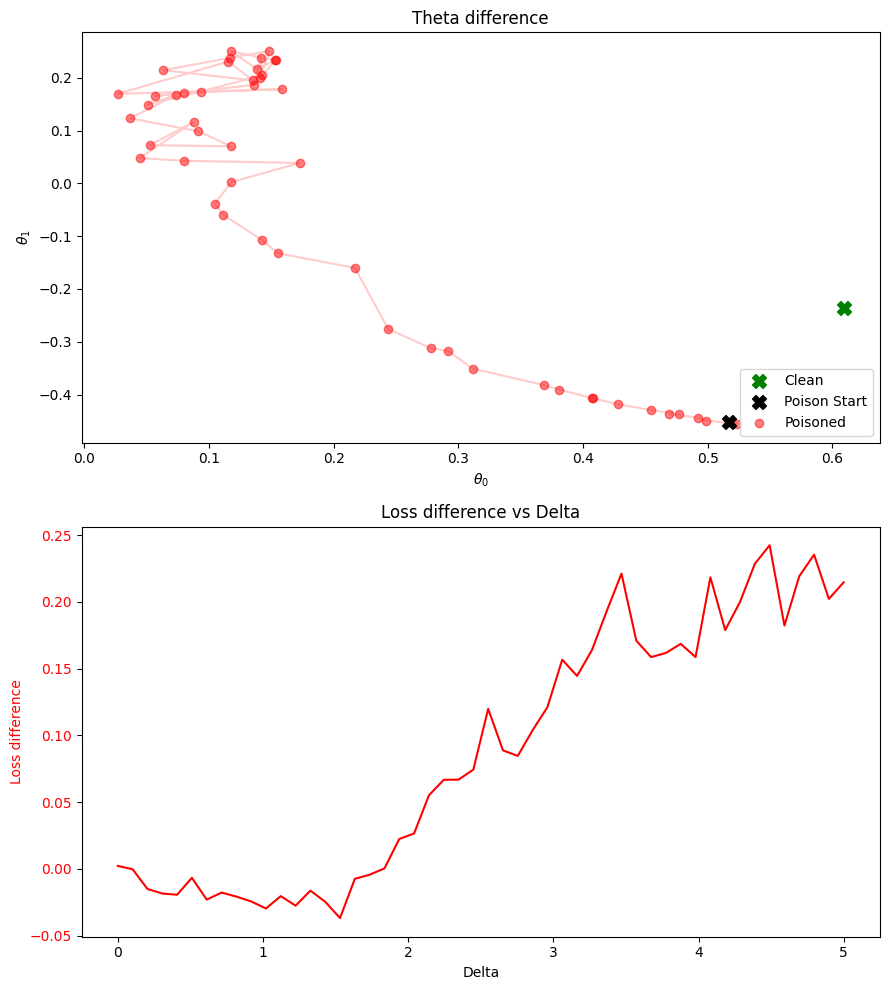

In [6]:
# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)

ax_theta.scatter(theta_clean[0], theta_clean[1], color='green', label='Clean', marker='X', s=100, zorder=5)
# Plot the start of the poisoned trajectory
ax_theta.scatter(theta_poisoned[0,0], theta_poisoned[0,1], color='black', label='Poison Start', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:,0], theta_poisoned[:,1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:,0], theta_poisoned[:,1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')

# Combined legend for theta subplot
ax_theta.legend(loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference vs Delta')

plt.tight_layout()
plt.show()

### Save Results

In [7]:
# import pickle

# pickle.dump({"delta_vals": delta_vals, "theta_diff": np.linalg.norm(theta_poisoned - theta_clean.numpy(), axis=-1), "loss_diff": losses_poisoned - loss_clean}, open("black_box_shadow_rgd_delta_sweep.pkl", "wb"))

## PerfGD + Shadow Model Untargeted

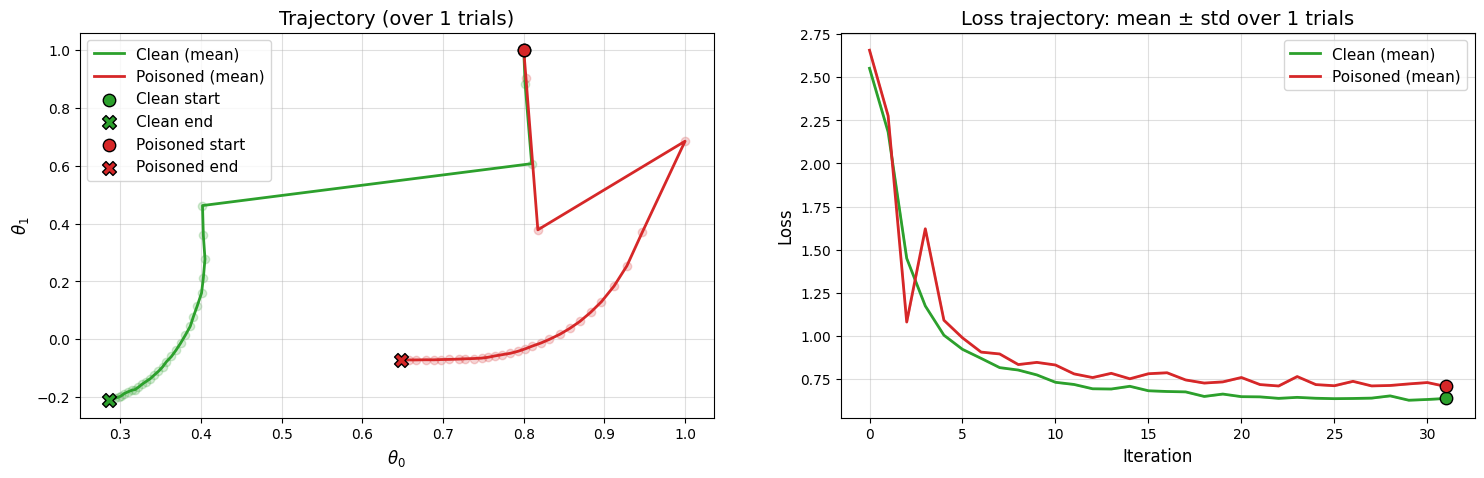

In [8]:
black_box_poison_function = black_box_shadow_logreg

n_trials = 1

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1

theta_0 = torch.tensor([0.8, 1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot theta and loss gap vs. delta

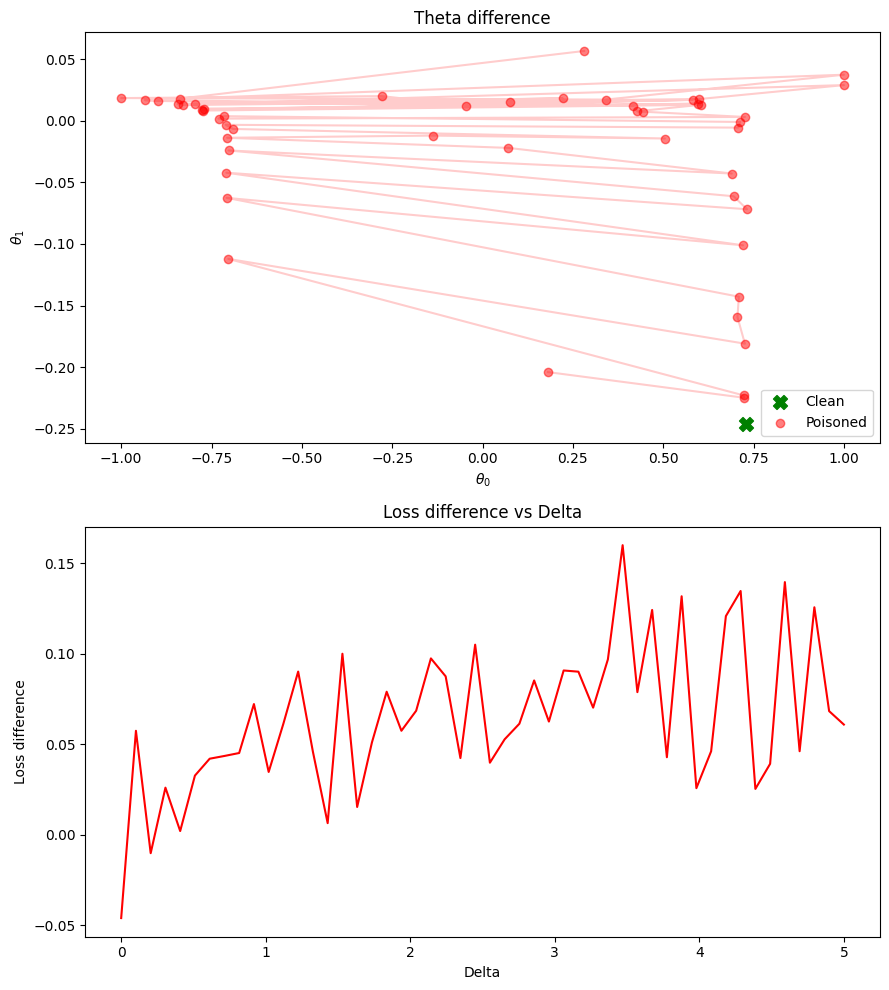

In [9]:
black_box_poison_function = black_box_shadow_logreg
delta_vals = np.linspace(0.0, 5, 50)
epsilon = 0.5

theta_clean, _, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    # print(f"delta: {delta}")
    _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned)

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)

ax_theta.scatter(theta_clean[0], theta_clean[1], color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:,0], theta_poisoned[:,1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:,0], theta_poisoned[:,1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')

# Combined legend for theta subplot
ax_theta.legend(loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='black')
ax_loss.tick_params(axis='y', labelcolor='black')
ax_loss.set_title('Loss difference vs Delta')

plt.tight_layout()
plt.show()

### Save Results

In [10]:
# import pickle

# pickle.dump({"delta_vals": delta_vals, "theta_diff": np.linalg.norm(theta_poisoned - theta_clean.numpy(), axis=-1), "loss_diff": losses_poisoned - loss_clean}, open("black_box_shadow_perfgd_delta_sweep.pkl", "wb"))

# 10D Binary Classification

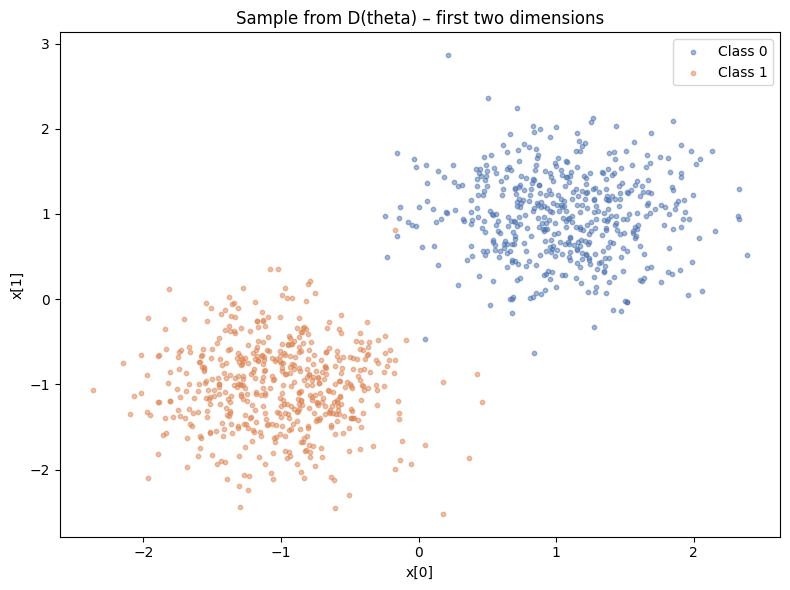

In [11]:
dim = 10
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification_nd(dim=dim, perfGD=True)

z = D_theta(theta_0, 1000)
x = z[:-1, :]  # (dim, n)
y = z[-1, :]   # (n,)

colors = ['#4C72B0', '#DD8452']
x0 = x[:, (y == 0).bool()].numpy()
x1 = x[:, (y == 1).bool()].numpy()

# Scatter: first two dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(x0[0], x0[1], alpha=0.5, color=colors[0], label='Class 0', s=10)
ax.scatter(x1[0], x1[1], alpha=0.5, color=colors[1], label='Class 1', s=10)
ax.set_xlabel('x[0]')
ax.set_ylabel('x[1]')
ax.set_title('Sample from D(theta) – first two dimensions')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## Untargeted Shadow Model Poisoning (nD)

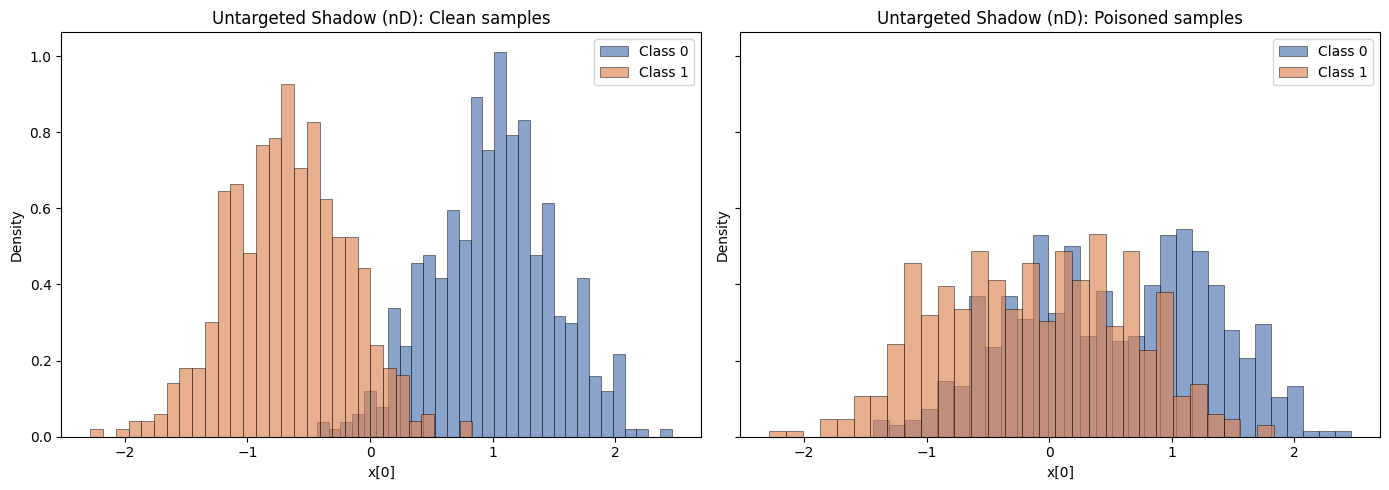

In [30]:
black_box_poison_function = black_box_shadow_logreg_nd  # nD: use _nd (z is (dim+1, n))
epsilon = 0.5
delta = 1.0
n = 1000
eta = 0.05
max_iter = 30
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

_, _, z_clean, z_poisoned = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    poison_function=black_box_poison_function,
    normalize_grad=False,
    return_samples=True,
    epsilon=epsilon,
    delta=delta
)

# For nD, plot first feature dimension only (clean vs poisoned by class)
x_clean = z_clean[:-1, :].numpy()
y_clean = z_clean[-1, :].numpy()
x_poison = z_poisoned[:-1, :].numpy()
y_poison = z_poisoned[-1, :].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, x_arr, y_arr, title in [(ax1, x_clean, y_clean, 'Clean'), (ax2, x_poison, y_poison, 'Poisoned')]:
    ax.hist(x_arr[0, (y_arr == 0)], bins=30, density=True, alpha=0.65, color=colors[0], edgecolor='k', linewidth=0.5, label='Class 0')
    ax.hist(x_arr[0, (y_arr == 1)], bins=30, density=True, alpha=0.65, color=colors[1], edgecolor='k', linewidth=0.5, label='Class 1')
    ax.set_xlabel('x[0]')
    ax.set_ylabel('Density')
    ax.set_title(f'Untargeted Shadow (nD): {title} samples')
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## RGD + Shadow Model Untargeted (nD)

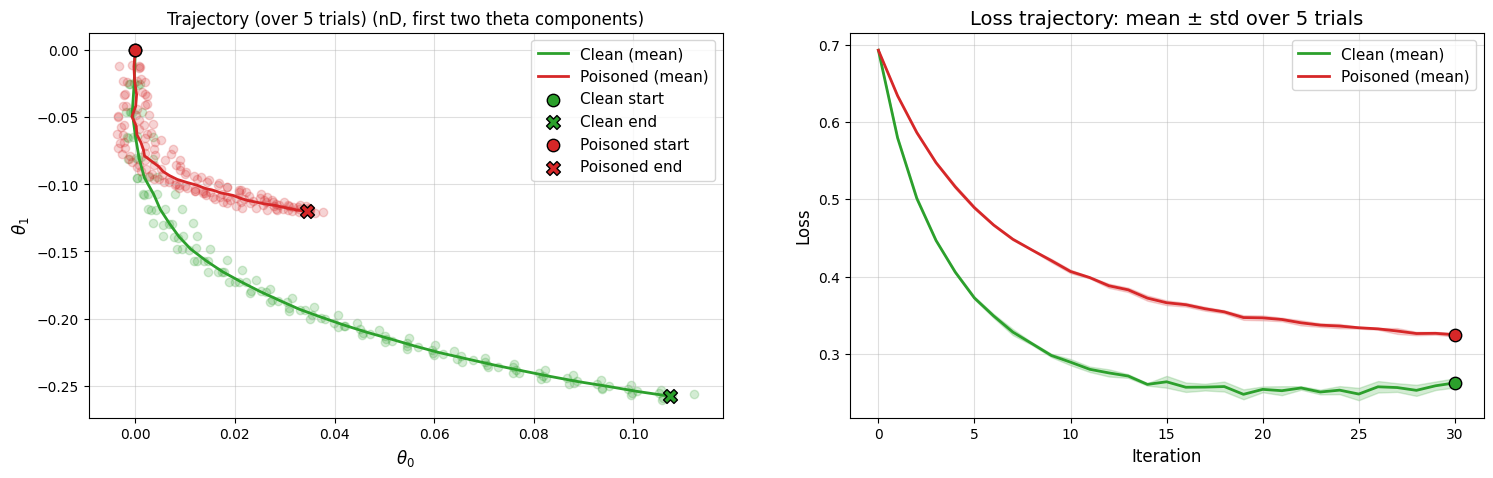

In [31]:
n_trials = 5
n = 500
theta_0 = torch.zeros(dim + 1)

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        normalize_grad=False,
        return_losses=True
    )
    _, all_theta_poisoned, all_losses_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        normalize_grad=False,
        return_losses=True,
        poison_function=black_box_poison_function,
        epsilon=epsilon,
        delta=delta,
    )
    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    tc, tp, lc, lp = run_trial()
    all_theta_clean_list.append(tc)
    all_theta_poisoned_list.append(tp)
    all_loss_clean_list.append(lc)
    all_loss_poisoned_list.append(lp)

# plot_results_2d plots first two components of theta
fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, all_theta_poisoned_list, all_loss_clean_list, all_loss_poisoned_list)
ax1.set_title(ax1.get_title() + ' (nD, first two theta components)')
plt.show()

### Plot theta and loss gap vs. delta (RGD, nD)

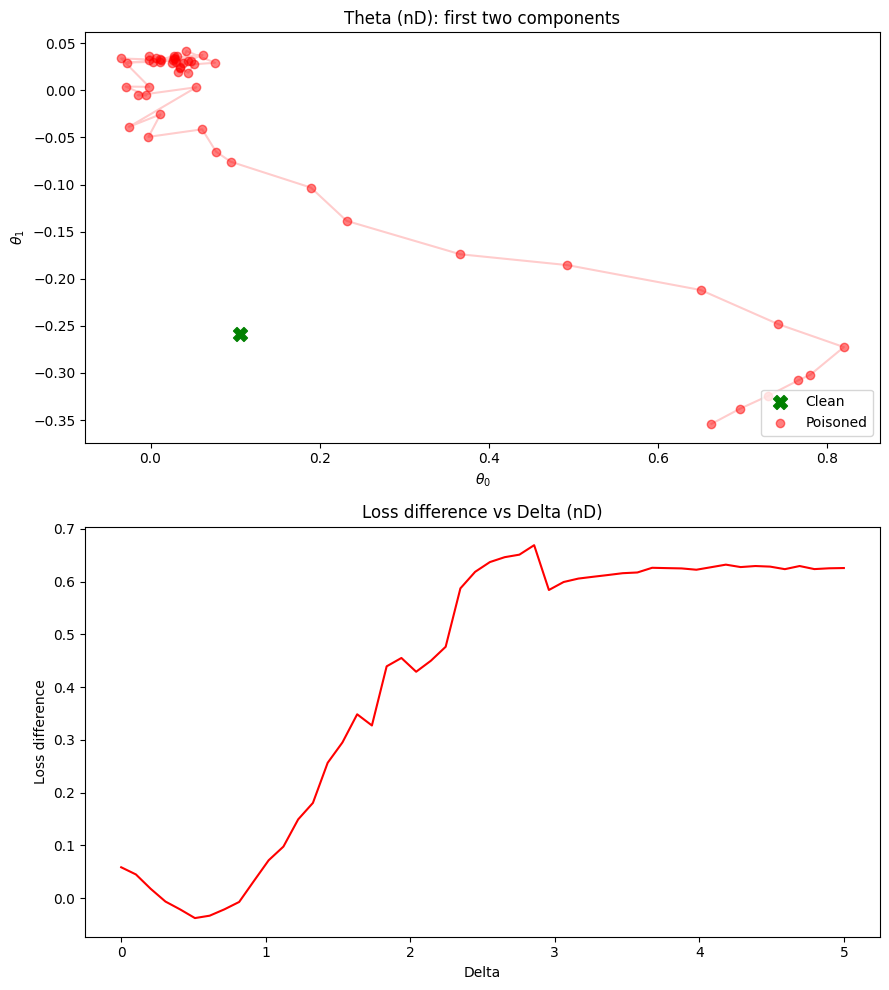

In [14]:
delta_vals = np.linspace(0.0, 5, 50)

theta_clean, _, all_losses_clean = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    proj_theta=proj_theta,
    n=n,
    eta=eta,
    max_iter=max_iter,
    normalize_grad=False,
    return_losses=True
)
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for d in delta_vals:
    _theta, _, all_losses, _ = RGD_audit(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        proj_theta=proj_theta,
        n=n,
        eta=eta,
        max_iter=max_iter,
        poison_function=black_box_poison_function,
        epsilon=epsilon,
        delta=d,
        last_step_only=False
    )
    losses_poisoned.append(all_losses[-1])
    theta_poisoned.append(_theta)

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.stack([t.detach().numpy() for t in theta_poisoned])

fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)
ax_theta.scatter(theta_clean[0].item(), theta_clean[1].item(), color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:, 0], theta_poisoned[:, 1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:, 0], theta_poisoned[:, 1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$')
ax_theta.set_xlabel(r'$\theta_0$')
ax_theta.set_title('Theta (nD): first two components')
ax_theta.legend(loc='lower right')

ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference')
ax_loss.set_title('Loss difference vs Delta (nD)')
plt.tight_layout()
plt.show()

## PerfGD + Shadow Model Untargeted (nD)

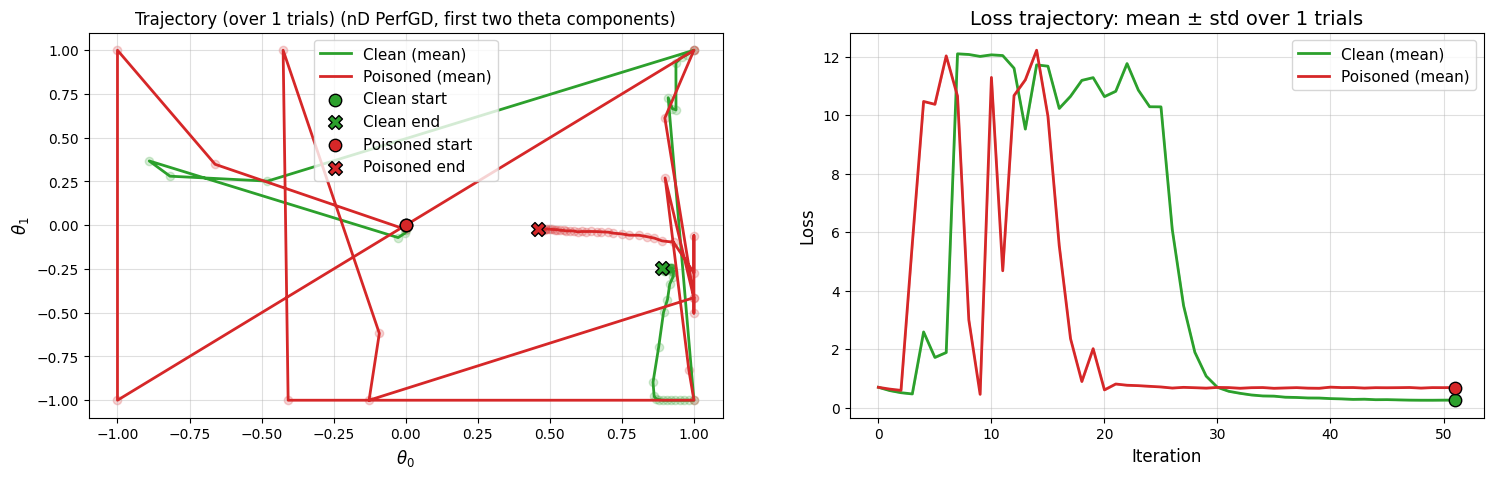

In [29]:
n_trials = 1

n = 500
eta = 0.05
max_iter = 50

epsilon = 0.5
delta = 1.0

theta_0 = torch.zeros(dim + 1)  # nD: must match (dim+1,) for loss/D_theta
# theta_0[0] = 0.8  # bias
# theta_0[1] = 1.0  # feature coefficients

def run_trial_perfgd():
    _, all_theta_clean, all_losses_clean = PerfGD(
        f_hat=f_hat,
        grad2_est=grad2_est,
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        proj_theta=proj_theta,
        n=n,
        eta=eta,
        max_iter=max_iter,
        normalize_grad=False,
        return_losses=True,
    )
    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
        f_hat=f_hat,
        grad2_est=grad2_est,
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        proj_theta=proj_theta,
        n=n,
        eta=eta,
        max_iter=max_iter,
        normalize_grad=False,
        return_losses=True,
        poison_function=black_box_poison_function,
        epsilon=epsilon,
        delta=delta,
    )
    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    tc, tp, lc, lp = run_trial_perfgd()
    all_theta_clean_list.append(tc)
    all_theta_poisoned_list.append(tp)
    all_loss_clean_list.append(lc)
    all_loss_poisoned_list.append(lp)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, all_theta_poisoned_list, all_loss_clean_list, all_loss_poisoned_list)
ax1.set_title(ax1.get_title() + ' (nD PerfGD, first two theta components)')
plt.show()

### Plot theta and loss gap vs. delta (PerfGD, nD)

TypeError: unsupported operand type(s) for -: 'list' and 'float'

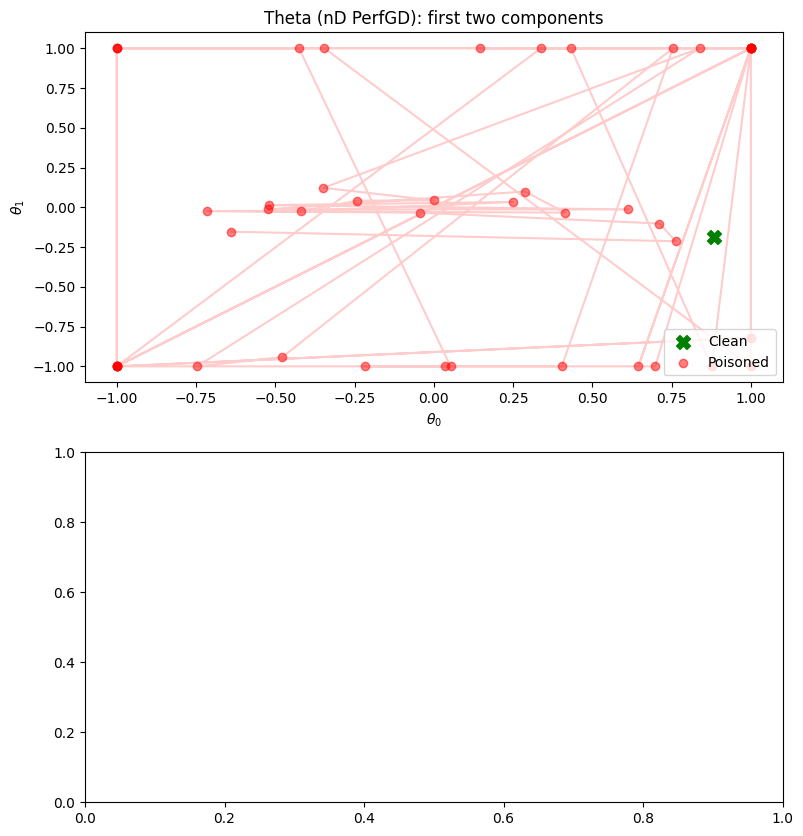

In [22]:
theta_clean, _, all_losses_clean = PerfGD(
    f_hat=f_hat,
    grad2_est=grad2_est,
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    proj_theta=proj_theta,
    n=n,
    eta=eta,
    max_iter=max_iter,
    normalize_grad=False,
    return_losses=True
)
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for d in delta_vals:
    _theta, _, all_losses = PerfGD(
        f_hat=f_hat,
        grad2_est=grad2_est,
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        proj_theta=proj_theta,
        n=n,
        eta=eta,
        max_iter=max_iter,
        normalize_grad=False,
        return_losses=True,
        poison_function=black_box_poison_function,
        epsilon=epsilon,
        delta=d,
    )
    losses_poisoned.append(all_losses[-1])
    theta_poisoned.append(_theta)

theta_poisoned = np.stack([t.detach().numpy() for t in theta_poisoned])

fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)
ax_theta.scatter(theta_clean[0].item(), theta_clean[1].item(), color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:, 0], theta_poisoned[:, 1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:, 0], theta_poisoned[:, 1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$')
ax_theta.set_xlabel(r'$\theta_0$')
ax_theta.set_title('Theta (nD PerfGD): first two components')
ax_theta.legend(loc='lower right')
ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference')
ax_loss.set_title('Loss difference vs Delta (nD PerfGD)')
plt.tight_layout()
plt.show()